# FeLIF

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from snntorch.functional import probe
from torch import nn

from eleanor.torch import models

In [5]:
tau_p = 1.07106568069094e-3
tau_m = 17.08904771900422e-3
threshold = 1
dt = 1e-6
Ps = 76.07685578175987
alpha = 1.29208951288980767
beta = 0.08717596748142253

model = nn.Sequential(
    models.FeLIF(
        tau_p=tau_p,
        tau_m=tau_m,
        threshold=threshold,
        dt=dt,
        P_s=Ps,
        alpha=alpha,
        beta=beta,
        variability=0.1,
    )
)

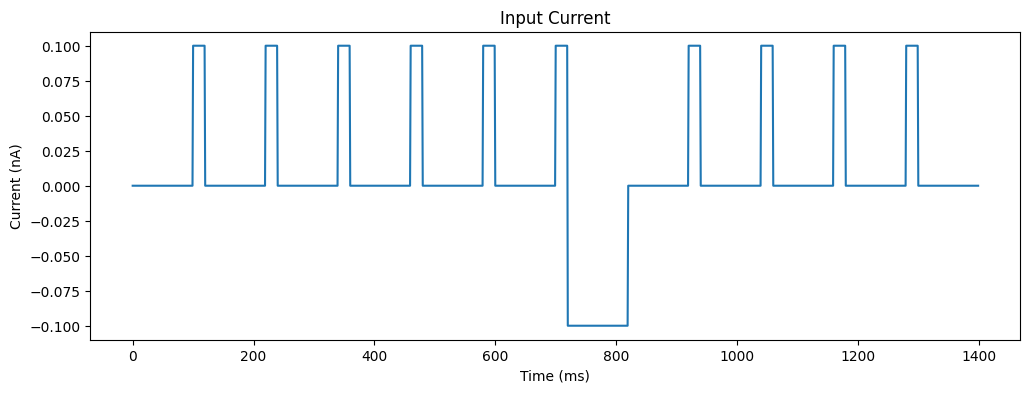

In [6]:
N = 50
AMPLITUDE = 0.1
input_1 = torch.concatenate(
    [torch.zeros(N, 100), torch.zeros(N, 20) + AMPLITUDE], dim=1
)
input_1 = [input_1 for _ in range(6)]

input_2 = torch.concatenate(
    [torch.zeros(N, 100) - AMPLITUDE, torch.zeros(N, 100)], dim=1
)

input_3 = torch.concatenate(
    [torch.zeros(N, 20) + AMPLITUDE, torch.zeros(N, 100)], dim=1
)
input_3 = [input_3 for _ in range(4)]

input = torch.cat(input_1 + [input_2] + input_3, dim=1)

plt.figure(figsize=(12, 4))
plt.plot(input[0])
plt.title("Input Current")
plt.xlabel("Time (ms)")
plt.ylabel("Current (nA)")
plt.show()

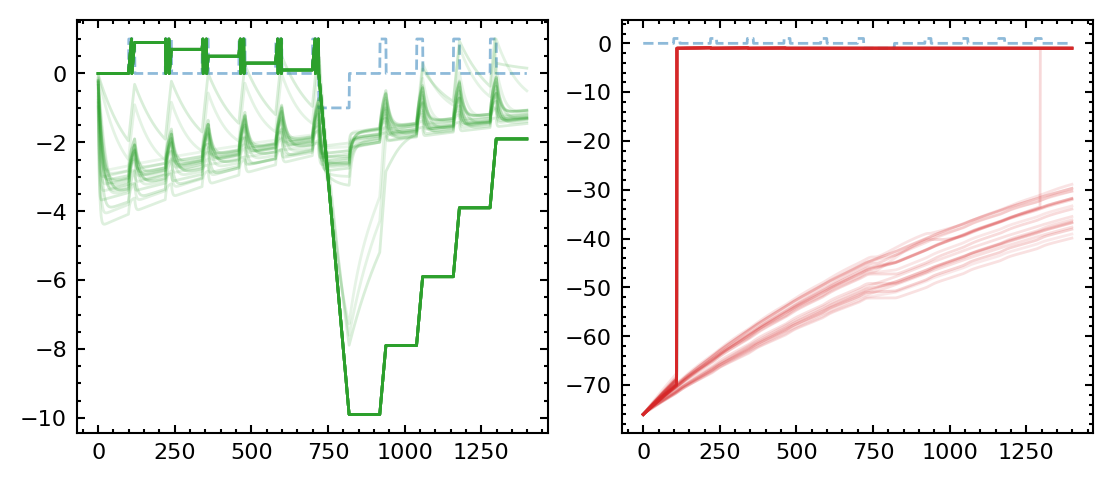

In [7]:
mem_monitor = probe.AttributeMonitor("mem", False, model, instance=models.FeLIF)
pol_monitor = probe.AttributeMonitor("pol", False, model, instance=models.FeLIF)

for t in range(input.shape[1]):
    model(input[:, t])

alphas = np.linspace(0.1, 0.2, N)

with mpl.style.context("boilerplot.ieeetran"):
    fig, ax = plt.subplots(1, 2, figsize=(5.45, 2.3), dpi=200)
    ax[0].plot(input[0] / AMPLITUDE, "--", alpha=0.5)
    # ax[0].plot(torch.stack(mem_monitor['0']), 'tab:blue')
    for line, alpha in zip(torch.stack(mem_monitor["0"]).T, alphas):
        ax[0].plot(line, color="tab:green", alpha=alpha)

    ax[1].plot(input[0] / AMPLITUDE, "--", alpha=0.5)
    for line, alpha in zip(torch.stack(pol_monitor["0"]).T, alphas):
        ax[1].plot(line, color="tab:red", alpha=alpha)
    plt.show()